In [ ]:
import glob
import pandas as pd

In [ ]:
# Path to the folder containing your labeled feature files
file_path = './features-new/*.csv'

# Read and combine all files into a single DataFrame
all_files = glob.glob(file_path)
dataframes = []

for file in all_files:
    df = pd.read_csv(file)
    
    # Process each video group
    def interleave_group(group):
        # First, sort by frame number so duplicates are consecutive
        group = group.sort_values('frame number')
        # Create a duplicate index for each occurrence of a frame
        group['dup_index'] = group.groupby('frame number').cumcount()
        # Now, sort by the duplicate index first, then by frame number to interleave
        group = group.sort_values(['dup_index', 'frame number']).drop(columns='dup_index')
        return group

    df = df.groupby('video number', group_keys=False).apply(interleave_group).reset_index(drop=True)
    dataframes.append(df)

combined_data = pd.concat(dataframes, ignore_index=True)

# Save the combined dataset for reference (optional)
combined_data.to_csv('./features-new/combined_labeled_features_sorted.csv', index=False)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and metrics
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score
from sklearn.utils import class_weight

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

from focal_loss import BinaryFocalLoss

In [2]:
# ===============================
# Configuration & Hyperparameters
# ===============================
SEQUENCE_LENGTH = 100    # ~4 seconds if 25 fps
STEP_SIZE = 1            # Overlapping window shift
N_FOLDS = 4              # # of cross-validation folds on the training videos
N_LSTM_UNITS = 512       # LSTM units
DROPOUT_RATE = 0.5       # Dropout
LEARNING_RATE = 1e-4     # LR for Adam
BATCH_SIZE = 64          # Batch size
EPOCHS = 20              # Max # of epochs
PATIENCE = 5             # Early stopping patience

# If you have focal_loss installed and want it, set True:
USE_FOCAL_LOSS = False
try:
    if USE_FOCAL_LOSS:
        from focal_loss import BinaryFocalLoss
except ImportError:
    print("focal_loss not installed. Using binary_crossentropy.")
    USE_FOCAL_LOSS = False

# ===============================
# Columns & Data Loading
# ===============================
feature_cols = [
    'mouth_width', 'lip_distance', 'wrist_to_mouth_distance',
    'left_ear_to_lip', 'jaw_to_nose'
    #'wrist_to_mouth_distance', 'wrist_to_mouth_velocity', 'right_ear_to_lip'
    #'eyebrow_distance', 'vertical_face_angle', 'vertical_gaze_angle',
    #'horizontal_gaze_angle'
]

label_cols = ['speaking', 'eating', 'smiling', 'fork_towards', 'action']

# Load your merged CSV (already sorted & interleaved as needed)
data = pd.read_csv('./features-new/combined_labeled_features_sorted.csv')

In [ ]:
# Create a person column from duplicate frames if not already present.
# This assumes that for each video and frame, the rows are ordered such that
# the first occurrence is person 0 and the second is person 1.
def assign_person(df):
    def assign_for_group(group):
        # Assuming there are exactly 2 entries per frame.
        group = group.sort_values('frame number')
        # Create a 'person' column based on the order within each frame.
        group['person'] = group.groupby('frame number').cumcount()
        return group

    return df.groupby('video number', group_keys=False).apply(assign_for_group)

# Apply this function once to your DataFrame
data = assign_person(data)


In [3]:
# ===================================================
# Modified create_sequences: separate two individuals
# ===================================================
def create_sequences(df, feature_cols, label_col, sequence_length=SEQUENCE_LENGTH, step=STEP_SIZE):
    """
    For each video, we assume the first half of the rows correspond to Person 1,
    and the second half to Person 2. No sequence crosses from one person to another.
    If leftover frames are fewer than sequence_length, we discard them.
    """
    X_list, y_list, video_ids_list = [], [], []

    for vid, group in df.groupby('video number'):
        # Sort by frame number within this video
        group = group.sort_values(by=['frame number']).reset_index(drop=True)

        # Split into two halves: first half (person1), second half (person2)
        half = len(group) // 2  # floor division
        sub1 = group.iloc[:half]
        sub2 = group.iloc[half:]

        # Person 1 sequences
        feats1 = sub1[feature_cols].values
        labels1 = sub1[label_col].values
        for start_idx in range(0, len(feats1) - sequence_length + 1, step):
            seq_feat = feats1[start_idx : start_idx + sequence_length]
            seq_label = labels1[start_idx + sequence_length - 1]
            X_list.append(seq_feat)
            y_list.append(seq_label)
            video_ids_list.append(vid)

        # Person 2 sequences
        feats2 = sub2[feature_cols].values
        labels2 = sub2[label_col].values
        for start_idx in range(0, len(feats2) - sequence_length + 1, step):
            seq_feat = feats2[start_idx : start_idx + sequence_length]
            seq_label = labels2[start_idx + sequence_length - 1]
            X_list.append(seq_feat)
            y_list.append(seq_label)
            video_ids_list.append(vid)

    return np.array(X_list), np.array(y_list), np.array(video_ids_list)

In [4]:
def train_test_split_by_video(X, y, video_ids, test_size=0.2, shuffle=False, random_state=42):
    unique_vids = np.unique(video_ids)
    n_test = int(len(unique_vids) * test_size)
    if shuffle:
        rng = np.random.default_rng(seed=random_state)
        rng.shuffle(unique_vids)
    test_vids = unique_vids[-n_test:]
    train_vids = unique_vids[:-n_test]
    train_mask = np.isin(video_ids, train_vids)
    test_mask  = np.isin(video_ids, test_vids)
    return X[train_mask], X[test_mask], y[train_mask], y[test_mask], video_ids[train_mask], video_ids[test_mask]


In [5]:
# ===============================
# 3) Video-Based Cross Validation
# ===============================
def video_based_cv_split(vid_array, n_folds=4, shuffle=False, random_state=42):
    unique_vids = np.unique(vid_array)
    if shuffle:
        rng = np.random.default_rng(seed=random_state)
        rng.shuffle(unique_vids)
    fold_sizes = np.full(n_folds, len(unique_vids) // n_folds, dtype=int)
    fold_sizes[: len(unique_vids) % n_folds] += 1
    current = 0
    folds = []
    for fold_size in fold_sizes:
        start, stop = current, current + fold_size
        val_vids = unique_vids[start:stop]
        folds.append(val_vids)
        current = stop
    for fold_i in range(n_folds):
        val_vids = folds[fold_i]
        train_vids = np.concatenate([folds[j] for j in range(n_folds) if j != fold_i])
        train_idx = np.where(np.isin(vid_array, train_vids))[0]
        val_idx   = np.where(np.isin(vid_array, val_vids))[0]
        yield train_idx, val_idx

In [6]:
def fit_preprocessor(data_array, imputer=None, scaler=None):
    n_samples, seq_len, n_features = data_array.shape
    data_2d = data_array.reshape(-1, n_features)
    if imputer is None:
        imputer = SimpleImputer(strategy='mean')
        imputer.fit(data_2d)
    data_imputed = imputer.transform(data_2d)
    if scaler is None:
        scaler = StandardScaler()
        scaler.fit(data_imputed)
    data_scaled = scaler.transform(data_imputed)
    return data_scaled.reshape(n_samples, seq_len, n_features), imputer, scaler

In [7]:
# ===============================
# 5) Class Weights
# ===============================
def compute_class_weights(y):
    """
    Computes balanced class weights for binary classification.
    """
    classes = np.unique(y)
    weights = class_weight.compute_class_weight('balanced', classes=classes, y=y)
    return dict(zip(classes, weights))

In [8]:
def build_model(input_shape,
                learning_rate=LEARNING_RATE,
                dropout_rate=DROPOUT_RATE,
                n_lstm_units=N_LSTM_UNITS,
                use_focal_loss=USE_FOCAL_LOSS):
    model = Sequential([
        Bidirectional(LSTM(n_lstm_units, return_sequences=True, dropout=dropout_rate),
                      input_shape=input_shape),
        Bidirectional(LSTM(n_lstm_units, dropout=dropout_rate)),
        #Dense(128, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    loss_fn = 'binary_crossentropy'
    if use_focal_loss:
        from focal_loss import BinaryFocalLoss
        loss_fn = BinaryFocalLoss(gamma=1)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=loss_fn,
        metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
    )
    return model

In [9]:
def optimize_threshold(y_true, y_probs):
    thresholds = np.linspace(0, 1, 101)
    best_thr = 0.5
    best_f1 = 0.0
    for thr in thresholds:
        preds = (y_probs >= thr).astype(int)
        score = f1_score(y_true, preds)
        if score > best_f1:
            best_f1 = score
            best_thr = thr
    return best_thr, best_f1

In [10]:
def print_label_distribution(df, label):
    counts = df[label].value_counts(dropna=False)
    print(f"Label distribution for '{label}':\n{counts}")
    print("Ratio:\n", counts / counts.sum())


Training model for label: speaking
Label distribution for 'speaking':
speaking
0    209129
1    105617
Name: count, dtype: int64
Ratio:
 speaking
0    0.664437
1    0.335563
Name: count, dtype: float64
Total sequences created for 'speaking': 312766
Train sequences: (271470, 100, 5) Test sequences: (41296, 100, 5)

--- CV Fold 1/4 ---
Training fold label distribution: [127476  62588]
Validation fold label distribution: [51663 29743]


d:\sina-code\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 100, 1024)      │     2,121,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 1024)           │     6,295,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,418,305 (32.11 MB)

 Trainable params: 8,418,305 (32.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2970/2970 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step - accuracy: 0.6682 - loss: 0.6341 - precision: 0.3699 - recall: 0.0181
Epoch 1: val_loss improved from inf to 0.65775, saving model to best_speaking_fold1.keras
2970/2970 ━━━━━━━━━━━━━━━━━━━━ 3105s 1s/step - accuracy: 0.6682 - loss: 0.6341 - precision: 0.3699 - recall: 0.0181 - val_accuracy: 0.6347 - val_loss: 0.6578 - val_precision: 1.0000 - val_recall: 1.0086e-04 - learning_rate: 1.0000e-04
Epoch 2/20
2970/2970 ━━━━━━━━━━━━━━━━━━━━ 0s 913ms/step - accuracy: 0.6702 - loss: 0.6294 - precision: 0.4631 - recall: 0.0061
Epoch 2: val_loss did not improve from 0.65775
2970/2970 ━━━━━━━━━━━━━━━━━━━━ 3070s 1s/step - accuracy: 0.6702 - loss: 0.6294 - precision: 0.4631 - recall: 0.0061 - val_accuracy: 0.6346 - val_loss: 0.6601 - val_precision: 0.5143 - val_recall: 6.0518e-04 - learning_rate: 1.0000e-04
Epoch 3/20
2970/2970 ━━━━━━━━━━━━━━━━━━━━ 0s 863ms/step - accuracy: 0.6721 - loss: 0.6251 - precision: 0.5244 - recall: 0.0110
Epoch 3: Red

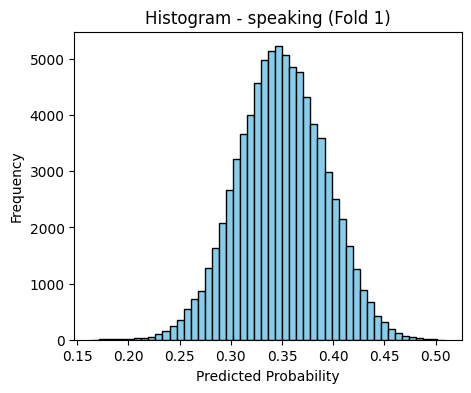

Confusion Matrix for Fold 1:
[[    0 51663]
 [    0 29743]]


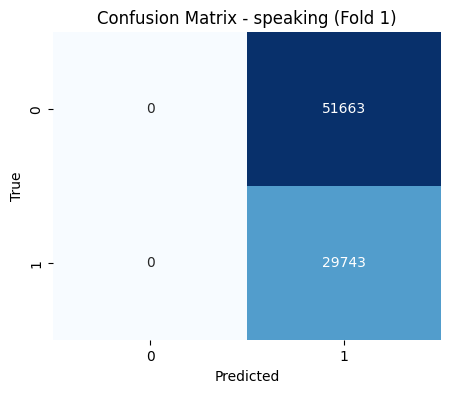


--- CV Fold 2/4 ---
Training fold label distribution: [134035  78663]
Validation fold label distribution: [45104 13668]


d:\sina-code\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 100, 1024)      │     2,121,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 1024)           │     6,295,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,418,305 (32.11 MB)

 Trainable params: 8,418,305 (32.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 0s 831ms/step - accuracy: 0.6251 - loss: 0.6613 - precision: 0.3932 - recall: 0.0191
Epoch 1: val_loss improved from inf to 0.59547, saving model to best_speaking_fold2.keras
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 3009s 905ms/step - accuracy: 0.6251 - loss: 0.6613 - precision: 0.3932 - recall: 0.0191 - val_accuracy: 0.7673 - val_loss: 0.5955 - val_precision: 0.4444 - val_recall: 0.0018 - learning_rate: 1.0000e-04
Epoch 2/20
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 0s 836ms/step - accuracy: 0.6312 - loss: 0.6551 - precision: 0.4988 - recall: 0.0077
Epoch 2: val_loss did not improve from 0.59547
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 2997s 902ms/step - accuracy: 0.6312 - loss: 0.6551 - precision: 0.4988 - recall: 0.0077 - val_accuracy: 0.7630 - val_loss: 0.5983 - val_precision: 0.2077 - val_recall: 0.0067 - learning_rate: 1.0000e-04
Epoch 3/20
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 0s 817ms/step - accuracy: 0.6306 - loss: 0.6530 - precision: 0.5166 - recall: 0.0205
Epoch 3: Reduc

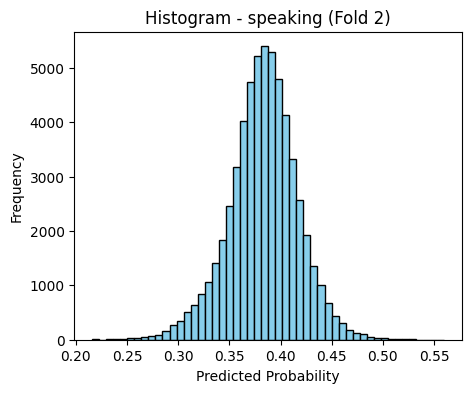

Confusion Matrix for Fold 2:
[[    9 45095]
 [    0 13668]]


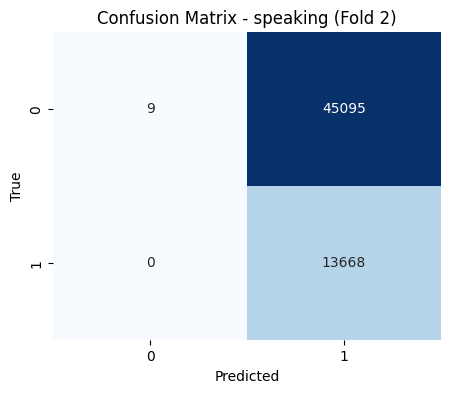


--- CV Fold 3/4 ---
Training fold label distribution: [141626  69522]
Validation fold label distribution: [37513 22809]


d:\sina-code\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 100, 1024)      │     2,121,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 1024)           │     6,295,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,418,305 (32.11 MB)

 Trainable params: 8,418,305 (32.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 0s 823ms/step - accuracy: 0.6642 - loss: 0.6373 - precision: 0.3707 - recall: 0.0195
Epoch 1: val_loss improved from inf to 0.66283, saving model to best_speaking_fold3.keras
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 2963s 897ms/step - accuracy: 0.6642 - loss: 0.6373 - precision: 0.3707 - recall: 0.0195 - val_accuracy: 0.6218 - val_loss: 0.6628 - val_precision: 0.2857 - val_recall: 8.7685e-05 - learning_rate: 1.0000e-04
Epoch 2/20
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 0s 825ms/step - accuracy: 0.6711 - loss: 0.6295 - precision: 0.4990 - recall: 0.0062
Epoch 2: val_loss did not improve from 0.66283
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 2971s 900ms/step - accuracy: 0.6711 - loss: 0.6295 - precision: 0.4990 - recall: 0.0062 - val_accuracy: 0.6219 - val_loss: 0.6641 - val_precision: 0.4615 - val_recall: 2.6305e-04 - learning_rate: 1.0000e-04
Epoch 3/20
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 0s 820ms/step - accuracy: 0.6714 - loss: 0.6279 - precision: 0.5482 - recall: 0.0107
Epoch 

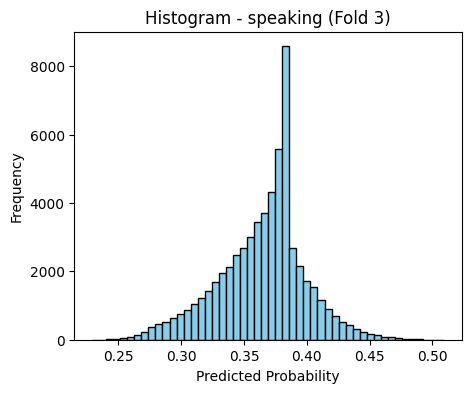

Confusion Matrix for Fold 3:
[[    0 37513]
 [    0 22809]]


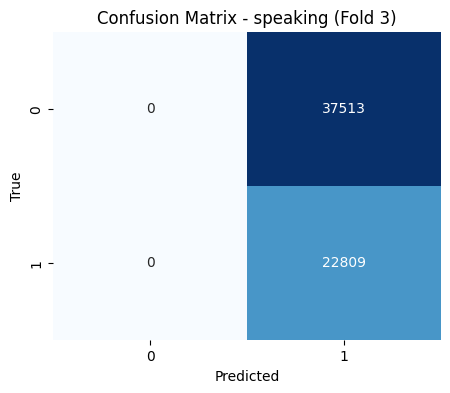


--- CV Fold 4/4 ---
Training fold label distribution: [134280  66220]
Validation fold label distribution: [44859 26111]


d:\sina-code\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_6 (Bidirectional) │ (None, 100, 1024)      │     2,121,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 1024)           │     6,295,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,418,305 (32.11 MB)

 Trainable params: 8,418,305 (32.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3133/3133 ━━━━━━━━━━━━━━━━━━━━ 0s 809ms/step - accuracy: 0.6651 - loss: 0.6384 - precision: 0.3408 - recall: 0.0148
Epoch 1: val_loss improved from inf to 0.66080, saving model to best_speaking_fold4.keras
3133/3133 ━━━━━━━━━━━━━━━━━━━━ 2827s 901ms/step - accuracy: 0.6651 - loss: 0.6384 - precision: 0.3408 - recall: 0.0148 - val_accuracy: 0.6321 - val_loss: 0.6608 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/20
3133/3133 ━━━━━━━━━━━━━━━━━━━━ 0s 807ms/step - accuracy: 0.6690 - loss: 0.6321 - precision: 0.4610 - recall: 0.0014
Epoch 2: val_loss improved from 0.66080 to 0.65761, saving model to best_speaking_fold4.keras
3133/3133 ━━━━━━━━━━━━━━━━━━━━ 2802s 894ms/step - accuracy: 0.6690 - loss: 0.6321 - precision: 0.4610 - recall: 0.0014 - val_accuracy: 0.6321 - val_loss: 0.6576 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/20
3133/3133 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.6698 - l

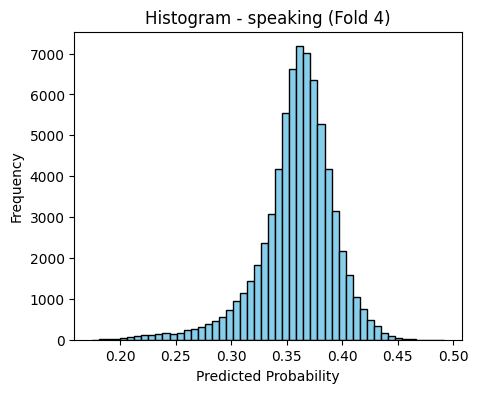

Confusion Matrix for Fold 4:
[[  495 44364]
 [  150 25961]]


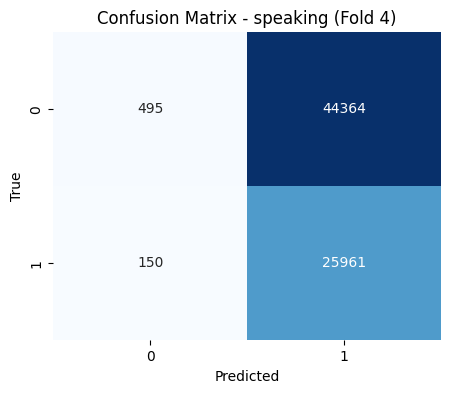


=== CV Summary for 'speaking' ===
Median threshold across folds: 0.115
Mean CV Accuracy: 0.6640
Avg best epoch: 1

--- Final Training for 'speaking' ---


d:\sina-code\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4242/4242 ━━━━━━━━━━━━━━━━━━━━ 0s 761ms/step - accuracy: 0.6569 - loss: 0.8544 - precision: 0.3370 - recall: 0.0082
Epoch 1: val_loss improved from inf to 0.64540, saving model to final_model_speaking.keras
4242/4242 ━━━━━━━━━━━━━━━━━━━━ 3385s 797ms/step - accuracy: 0.6569 - loss: 0.8544 - precision: 0.3370 - recall: 0.0082 - val_accuracy: 0.6909 - val_loss: 0.6454 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 1.

Final Model for 'speaking' => Test Loss: 0.6454, Test Acc: 0.6909
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 234s 138ms/step


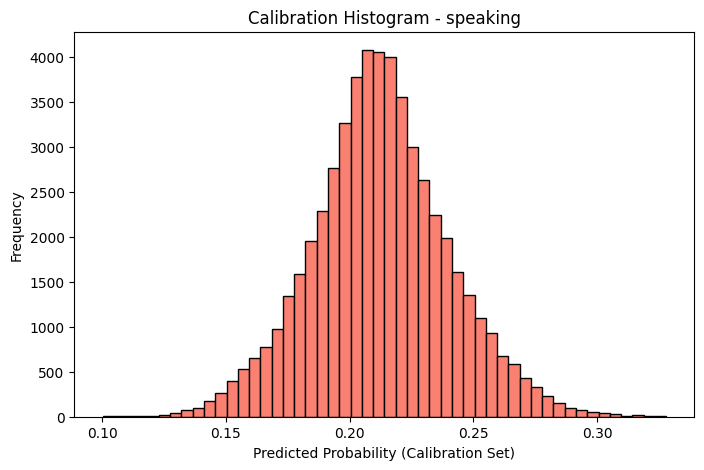

Optimal threshold on calibration set for 'speaking': 0.160, F1: 0.563
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 177s 137ms/step

Classification Report for 'speaking' (using calibrated threshold):
              precision    recall  f1-score   support

           0       0.80      0.05      0.09     28531
           1       0.31      0.98      0.47     12765

    accuracy                           0.33     41296
   macro avg       0.56      0.51      0.28     41296
weighted avg       0.65      0.33      0.21     41296

Test Confusion Matrix:
[[ 1306 27225]
 [  318 12447]]


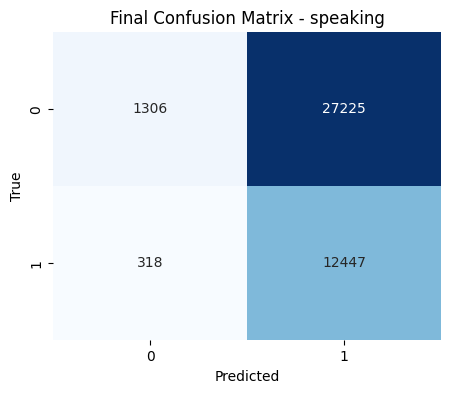

Model for 'speaking' saved as final_model_speaking.keras


Training model for label: eating
Label distribution for 'eating':
eating
0    196662
1    118084
Name: count, dtype: int64
Ratio:
 eating
0    0.624828
1    0.375172
Name: count, dtype: float64
Total sequences created for 'eating': 312766
Train sequences: (271470, 100, 5) Test sequences: (41296, 100, 5)

--- CV Fold 1/4 ---
Training fold label distribution: [121591  68473]
Validation fold label distribution: [50554 30852]


d:\sina-code\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_10                │ (None, 100, 1024)      │     2,121,728 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ (None, 1024)           │     6,295,552 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,418,305 (32.11 MB)

 Trainable params: 8,418,305 (32.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2970/2970 ━━━━━━━━━━━━━━━━━━━━ 0s 750ms/step - accuracy: 0.6355 - loss: 0.6430 - precision: 0.4830 - recall: 0.1022
Epoch 1: val_loss improved from inf to 0.66491, saving model to best_eating_fold1.keras
2970/2970 ━━━━━━━━━━━━━━━━━━━━ 2538s 854ms/step - accuracy: 0.6355 - loss: 0.6430 - precision: 0.4830 - recall: 0.1022 - val_accuracy: 0.6163 - val_loss: 0.6649 - val_precision: 0.3968 - val_recall: 0.0241 - learning_rate: 1.0000e-04
Epoch 2/20
2970/2970 ━━━━━━━━━━━━━━━━━━━━ 0s 746ms/step - accuracy: 0.6431 - loss: 0.6323 - precision: 0.5121 - recall: 0.1285
Epoch 2: val_loss did not improve from 0.66491
2970/2970 ━━━━━━━━━━━━━━━━━━━━ 2517s 848ms/step - accuracy: 0.6431 - loss: 0.6323 - precision: 0.5121 - recall: 0.1285 - val_accuracy: 0.6042 - val_loss: 0.6947 - val_precision: 0.4027 - val_recall: 0.0917 - learning_rate: 1.0000e-04
Epoch 3/20
2970/2970 ━━━━━━━━━━━━━━━━━━━━ 0s 746ms/step - accuracy: 0.6472 - loss: 0.6259 - precision: 0.5304 - recall: 0.1870
Epoch 3: ReduceL

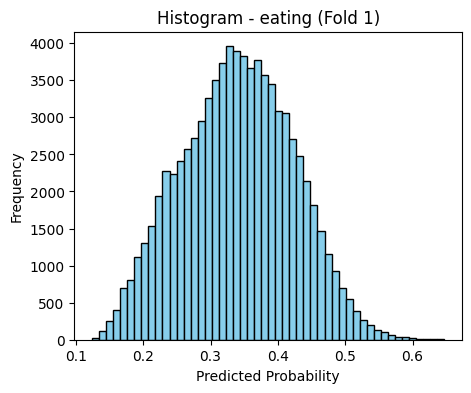

Confusion Matrix for Fold 1:
[[ 4996 45558]
 [ 1569 29283]]


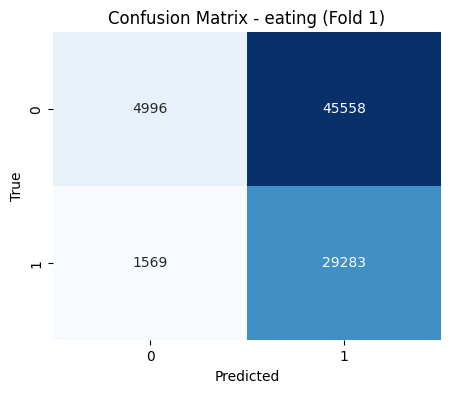


--- CV Fold 2/4 ---
Training fold label distribution: [137975  74723]
Validation fold label distribution: [34170 24602]


d:\sina-code\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_12                │ (None, 100, 1024)      │     2,121,728 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_13                │ (None, 1024)           │     6,295,552 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,418,305 (32.11 MB)

 Trainable params: 8,418,305 (32.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 0s 740ms/step - accuracy: 0.6420 - loss: 0.6419 - precision: 0.4484 - recall: 0.0604
Epoch 1: val_loss improved from inf to 0.67667, saving model to best_eating_fold2.keras
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 2684s 807ms/step - accuracy: 0.6420 - loss: 0.6419 - precision: 0.4484 - recall: 0.0604 - val_accuracy: 0.5785 - val_loss: 0.6767 - val_precision: 0.4250 - val_recall: 0.0195 - learning_rate: 1.0000e-04
Epoch 2/20
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 0s 734ms/step - accuracy: 0.6486 - loss: 0.6308 - precision: 0.4950 - recall: 0.0809
Epoch 2: val_loss did not improve from 0.67667
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 2697s 799ms/step - accuracy: 0.6486 - loss: 0.6308 - precision: 0.4950 - recall: 0.0809 - val_accuracy: 0.5761 - val_loss: 0.7201 - val_precision: 0.4145 - val_recall: 0.0307 - learning_rate: 1.0000e-04
Epoch 3/20
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 0s 732ms/step - accuracy: 0.6518 - loss: 0.6241 - precision: 0.5162 - recall: 0.1379
Epoch 3: ReduceL

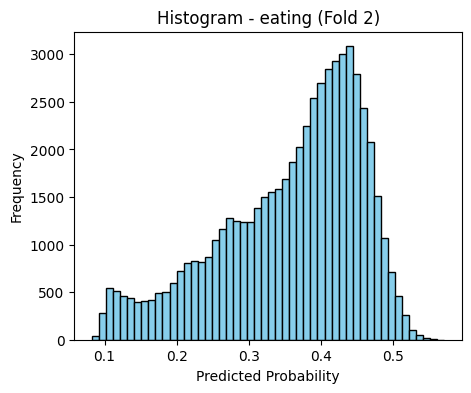

Confusion Matrix for Fold 2:
[[ 4985 29185]
 [ 1662 22940]]


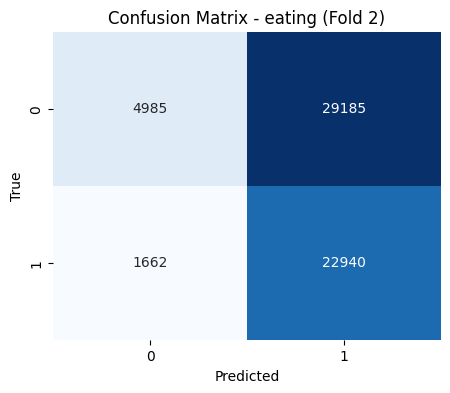


--- CV Fold 3/4 ---
Training fold label distribution: [133317  77831]
Validation fold label distribution: [38828 21494]


d:\sina-code\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_14                │ (None, 100, 1024)      │     2,121,728 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_15                │ (None, 1024)           │     6,295,552 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,418,305 (32.11 MB)

 Trainable params: 8,418,305 (32.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 0s 728ms/step - accuracy: 0.6278 - loss: 0.6485 - precision: 0.4916 - recall: 0.1193
Epoch 1: val_loss improved from inf to 0.69850, saving model to best_eating_fold3.keras
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 2636s 798ms/step - accuracy: 0.6278 - loss: 0.6485 - precision: 0.4916 - recall: 0.1193 - val_accuracy: 0.6176 - val_loss: 0.6985 - val_precision: 0.3139 - val_recall: 0.0616 - learning_rate: 1.0000e-04
Epoch 2/20
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 0s 728ms/step - accuracy: 0.6357 - loss: 0.6370 - precision: 0.5240 - recall: 0.1631
Epoch 2: val_loss did not improve from 0.69850
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 2626s 796ms/step - accuracy: 0.6357 - loss: 0.6370 - precision: 0.5240 - recall: 0.1631 - val_accuracy: 0.6180 - val_loss: 0.7078 - val_precision: 0.3300 - val_recall: 0.0701 - learning_rate: 1.0000e-04
Epoch 3/20
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 0s 726ms/step - accuracy: 0.6423 - loss: 0.6312 - precision: 0.5392 - recall: 0.1961
Epoch 3: val_los

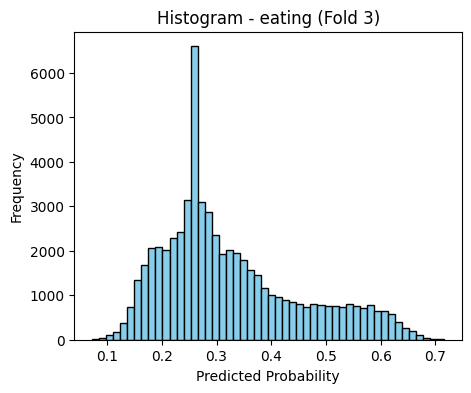

Confusion Matrix for Fold 3:
[[ 1899 36929]
 [  608 20886]]


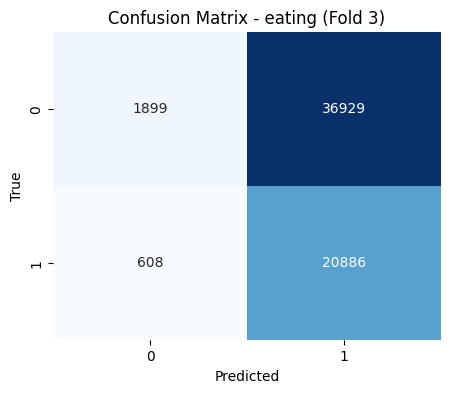


--- CV Fold 4/4 ---
Training fold label distribution: [123552  76948]
Validation fold label distribution: [48593 22377]


d:\sina-code\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_16                │ (None, 100, 1024)      │     2,121,728 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_17                │ (None, 1024)           │     6,295,552 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,418,305 (32.11 MB)

 Trainable params: 8,418,305 (32.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3133/3133 ━━━━━━━━━━━━━━━━━━━━ 0s 719ms/step - accuracy: 0.6122 - loss: 0.6585 - precision: 0.4756 - recall: 0.0891
Epoch 1: val_loss improved from inf to 0.64043, saving model to best_eating_fold4.keras
3133/3133 ━━━━━━━━━━━━━━━━━━━━ 2520s 804ms/step - accuracy: 0.6122 - loss: 0.6585 - precision: 0.4756 - recall: 0.0891 - val_accuracy: 0.6563 - val_loss: 0.6404 - val_precision: 0.4014 - val_recall: 0.1834 - learning_rate: 1.0000e-04
Epoch 2/20
3133/3133 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - accuracy: 0.6223 - loss: 0.6507 - precision: 0.5262 - recall: 0.1325
Epoch 2: val_loss improved from 0.64043 to 0.62783, saving model to best_eating_fold4.keras
3133/3133 ━━━━━━━━━━━━━━━━━━━━ 2513s 802ms/step - accuracy: 0.6223 - loss: 0.6507 - precision: 0.5262 - recall: 0.1325 - val_accuracy: 0.6619 - val_loss: 0.6278 - val_precision: 0.3478 - val_recall: 0.0827 - learning_rate: 1.0000e-04
Epoch 3/20
3133/3133 ━━━━━━━━━━━━━━━━━━━━ 0s 717ms/step - accuracy: 0.6254 - loss: 0.6478 - precis

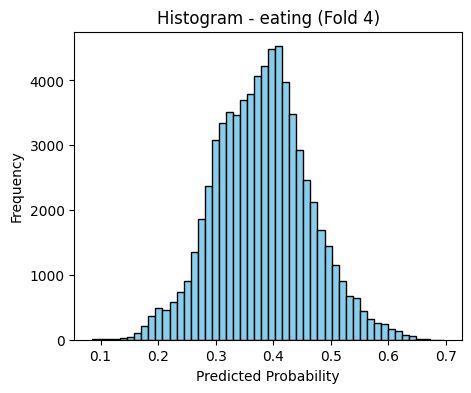

Confusion Matrix for Fold 4:
[[ 1994 46599]
 [  209 22168]]


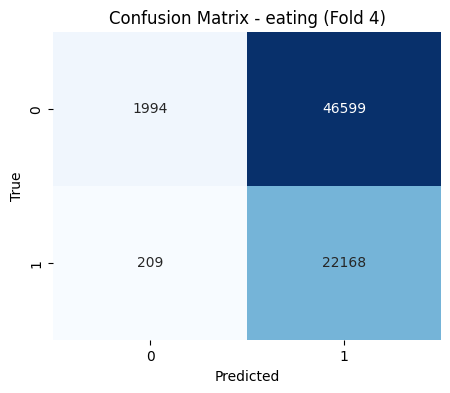


=== CV Summary for 'eating' ===
Median threshold across folds: 0.220
Mean CV Accuracy: 0.6149
Avg best epoch: 1

--- Final Training for 'eating' ---


d:\sina-code\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4242/4242 ━━━━━━━━━━━━━━━━━━━━ 0s 710ms/step - accuracy: 0.6327 - loss: 0.8694 - precision: 0.4573 - recall: 0.0100
Epoch 1: val_loss improved from inf to 0.81093, saving model to final_model_eating.keras
4242/4242 ━━━━━━━━━━━━━━━━━━━━ 3172s 747ms/step - accuracy: 0.6327 - loss: 0.8694 - precision: 0.4573 - recall: 0.0100 - val_accuracy: 0.5548 - val_loss: 0.8109 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 1.

Final Model for 'eating' => Test Loss: 0.8109, Test Acc: 0.5548
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 232s 136ms/step


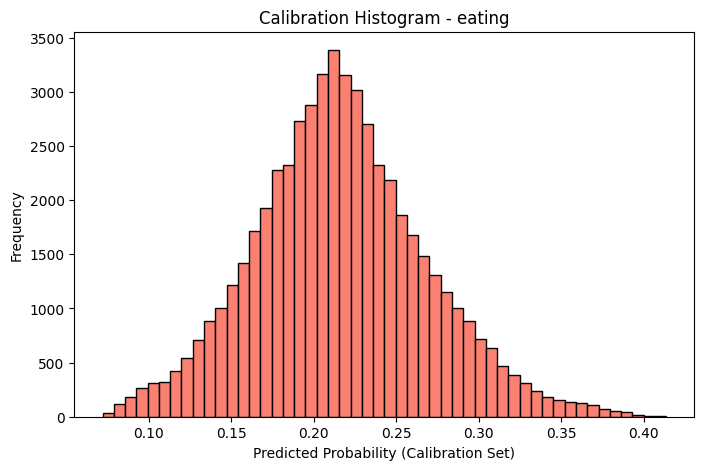

Optimal threshold on calibration set for 'eating': 0.210, F1: 0.487
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 176s 136ms/step

Classification Report for 'eating' (using calibrated threshold):
              precision    recall  f1-score   support

           0       0.60      0.45      0.51     22909
           1       0.48      0.62      0.54     18387

    accuracy                           0.53     41296
   macro avg       0.54      0.53      0.53     41296
weighted avg       0.54      0.53      0.52     41296

Test Confusion Matrix:
[[10319 12590]
 [ 6996 11391]]


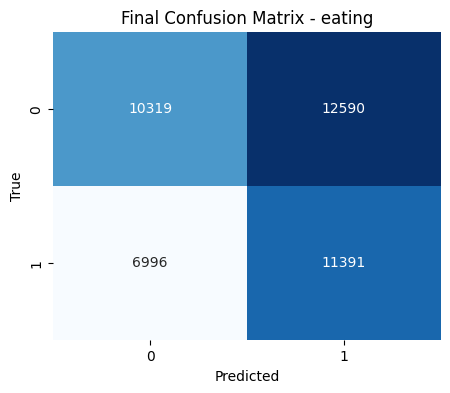

Model for 'eating' saved as final_model_eating.keras


Training model for label: smiling
Label distribution for 'smiling':
smiling
0    267520
1     47226
Name: count, dtype: int64
Ratio:
 smiling
0    0.849955
1    0.150045
Name: count, dtype: float64
Total sequences created for 'smiling': 312766
Train sequences: (271470, 100, 5) Test sequences: (41296, 100, 5)

--- CV Fold 1/4 ---
Training fold label distribution: [165486  24578]
Validation fold label distribution: [67164 14242]


d:\sina-code\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_20                │ (None, 100, 1024)      │     2,121,728 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_21                │ (None, 1024)           │     6,295,552 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,418,305 (32.11 MB)

 Trainable params: 8,418,305 (32.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2970/2970 ━━━━━━━━━━━━━━━━━━━━ 0s 707ms/step - accuracy: 0.8650 - loss: 0.3797 - precision: 0.4398 - recall: 0.0724
Epoch 1: val_loss improved from inf to 0.42011, saving model to best_smiling_fold1.keras
2970/2970 ━━━━━━━━━━━━━━━━━━━━ 2409s 810ms/step - accuracy: 0.8650 - loss: 0.3797 - precision: 0.4398 - recall: 0.0724 - val_accuracy: 0.8296 - val_loss: 0.4201 - val_precision: 0.9538 - val_recall: 0.0275 - learning_rate: 1.0000e-04
Epoch 2/20
2970/2970 ━━━━━━━━━━━━━━━━━━━━ 0s 707ms/step - accuracy: 0.8748 - loss: 0.3574 - precision: 0.6351 - recall: 0.0817
Epoch 2: val_loss improved from 0.42011 to 0.41243, saving model to best_smiling_fold1.keras
2970/2970 ━━━━━━━━━━━━━━━━━━━━ 2403s 809ms/step - accuracy: 0.8748 - loss: 0.3574 - precision: 0.6351 - recall: 0.0817 - val_accuracy: 0.8343 - val_loss: 0.4124 - val_precision: 0.8092 - val_recall: 0.0694 - learning_rate: 1.0000e-04
Epoch 3/20
2970/2970 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.8757 - loss: 0.3530 - prec

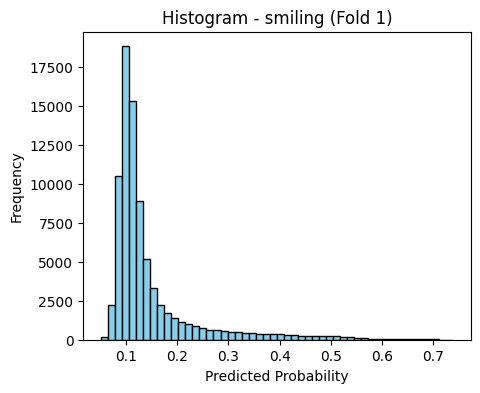

Confusion Matrix for Fold 1:
[[54996 12168]
 [ 6864  7378]]


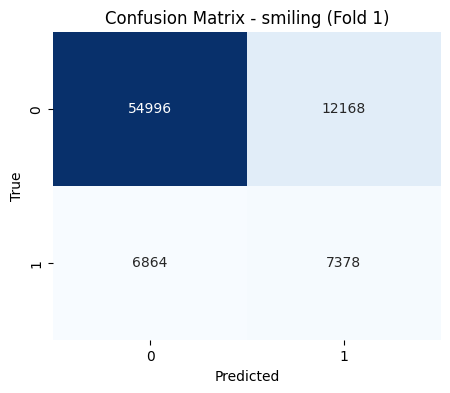


--- CV Fold 2/4 ---
Training fold label distribution: [183238  29460]
Validation fold label distribution: [49412  9360]


d:\sina-code\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_22                │ (None, 100, 1024)      │     2,121,728 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_23                │ (None, 1024)           │     6,295,552 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,418,305 (32.11 MB)

 Trainable params: 8,418,305 (32.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - accuracy: 0.8561 - loss: 0.3885 - precision: 0.4523 - recall: 0.0865
Epoch 1: val_loss improved from inf to 0.40708, saving model to best_smiling_fold2.keras
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 2562s 770ms/step - accuracy: 0.8561 - loss: 0.3885 - precision: 0.4523 - recall: 0.0865 - val_accuracy: 0.8500 - val_loss: 0.4071 - val_precision: 0.7142 - val_recall: 0.0969 - learning_rate: 1.0000e-04
Epoch 2/20
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - accuracy: 0.8651 - loss: 0.3653 - precision: 0.5651 - recall: 0.0923
Epoch 2: val_loss did not improve from 0.40708
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 2554s 768ms/step - accuracy: 0.8651 - loss: 0.3653 - precision: 0.5651 - recall: 0.0923 - val_accuracy: 0.8415 - val_loss: 0.4153 - val_precision: 0.5322 - val_recall: 0.0415 - learning_rate: 1.0000e-04
Epoch 3/20
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 0s 725ms/step - accuracy: 0.8674 - loss: 0.3568 - precision: 0.6111 - recall: 0.1302
Epoch 3: Reduce

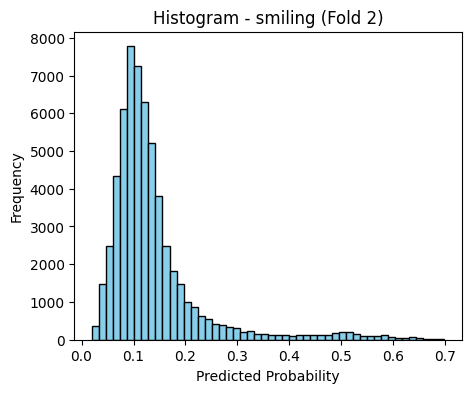

Confusion Matrix for Fold 2:
[[43296  6116]
 [ 5790  3570]]


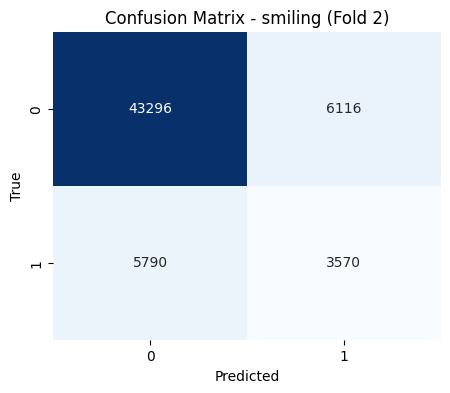


--- CV Fold 3/4 ---
Training fold label distribution: [176045  35103]
Validation fold label distribution: [56605  3717]


d:\sina-code\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_24                │ (None, 100, 1024)      │     2,121,728 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_25                │ (None, 1024)           │     6,295,552 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,418,305 (32.11 MB)

 Trainable params: 8,418,305 (32.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 0s 722ms/step - accuracy: 0.8303 - loss: 0.4310 - precision: 0.5028 - recall: 0.1181
Epoch 1: val_loss improved from inf to 0.25481, saving model to best_smiling_fold3.keras
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 2629s 796ms/step - accuracy: 0.8303 - loss: 0.4309 - precision: 0.5028 - recall: 0.1181 - val_accuracy: 0.9356 - val_loss: 0.2548 - val_precision: 0.0711 - val_recall: 0.0038 - learning_rate: 1.0000e-04
Epoch 2/20
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 0s 722ms/step - accuracy: 0.8411 - loss: 0.4068 - precision: 0.6063 - recall: 0.1265
Epoch 2: val_loss improved from 0.25481 to 0.25132, saving model to best_smiling_fold3.keras
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 2627s 796ms/step - accuracy: 0.8411 - loss: 0.4068 - precision: 0.6064 - recall: 0.1265 - val_accuracy: 0.9373 - val_loss: 0.2513 - val_precision: 0.0676 - val_recall: 0.0013 - learning_rate: 1.0000e-04
Epoch 3/20
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.8447 - loss: 0.3973 - prec

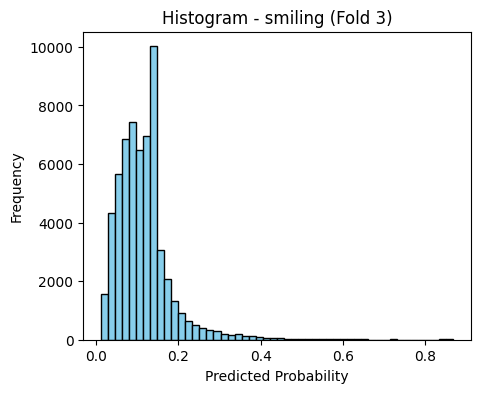

Confusion Matrix for Fold 3:
[[36656 19949]
 [ 1905  1812]]


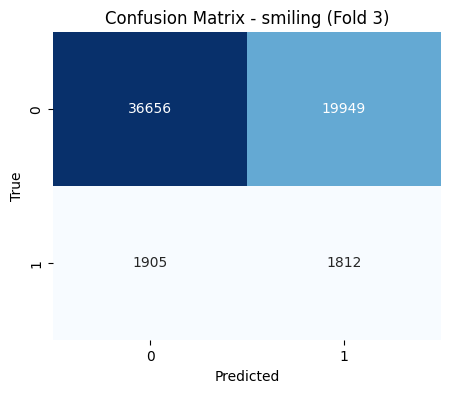


--- CV Fold 4/4 ---
Training fold label distribution: [173181  27319]
Validation fold label distribution: [59469 11501]


d:\sina-code\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_26                │ (None, 100, 1024)      │     2,121,728 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_27                │ (None, 1024)           │     6,295,552 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,418,305 (32.11 MB)

 Trainable params: 8,418,305 (32.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3133/3133 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.8586 - loss: 0.3862 - precision: 0.4868 - recall: 0.1008
Epoch 1: val_loss improved from inf to 0.43474, saving model to best_smiling_fold4.keras
3133/3133 ━━━━━━━━━━━━━━━━━━━━ 2553s 814ms/step - accuracy: 0.8586 - loss: 0.3862 - precision: 0.4868 - recall: 0.1008 - val_accuracy: 0.8385 - val_loss: 0.4347 - val_precision: 0.8136 - val_recall: 0.0042 - learning_rate: 1.0000e-04
Epoch 2/20
3133/3133 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.8688 - loss: 0.3657 - precision: 0.6422 - recall: 0.1039
Epoch 2: val_loss did not improve from 0.43474
3133/3133 ━━━━━━━━━━━━━━━━━━━━ 2545s 812ms/step - accuracy: 0.8688 - loss: 0.3657 - precision: 0.6422 - recall: 0.1039 - val_accuracy: 0.8387 - val_loss: 0.4376 - val_precision: 0.6667 - val_recall: 0.0097 - learning_rate: 1.0000e-04
Epoch 3/20
3133/3133 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.8712 - loss: 0.3579 - precision: 0.6493 - recall: 0.1055
Epoch 3: Reduce

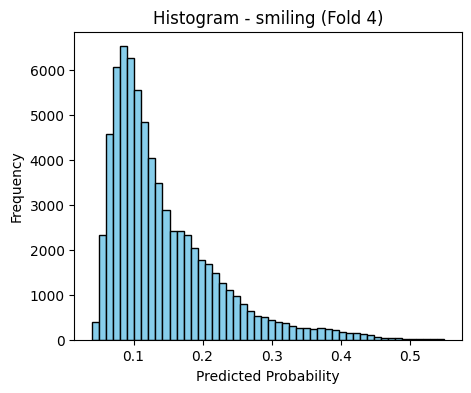

Confusion Matrix for Fold 4:
[[48205 11264]
 [ 7480  4021]]


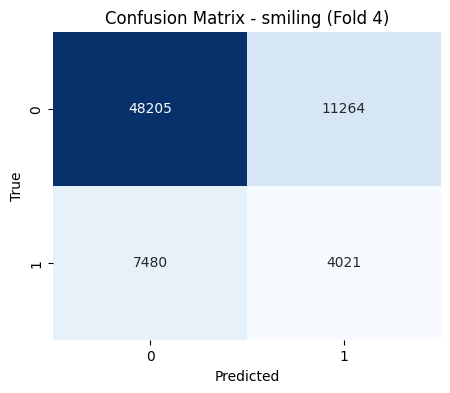


=== CV Summary for 'smiling' ===
Median threshold across folds: 0.165
Mean CV Accuracy: 0.8648
Avg best epoch: 2

--- Final Training for 'smiling' ---


d:\sina-code\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/2
4242/4242 ━━━━━━━━━━━━━━━━━━━━ 0s 720ms/step - accuracy: 0.8523 - loss: 0.5067 - precision: 0.4333 - recall: 0.0251
Epoch 1: val_loss improved from inf to 0.50302, saving model to final_model_smiling.keras
4242/4242 ━━━━━━━━━━━━━━━━━━━━ 3226s 760ms/step - accuracy: 0.8523 - loss: 0.5067 - precision: 0.4333 - recall: 0.0251 - val_accuracy: 0.8122 - val_loss: 0.5030 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/2
4242/4242 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.8601 - loss: 0.4716 - precision: 0.7411 - recall: 0.0307
Epoch 2: val_loss did not improve from 0.50302
4242/4242 ━━━━━━━━━━━━━━━━━━━━ 3226s 761ms/step - accuracy: 0.8601 - loss: 0.4716 - precision: 0.7411 - recall: 0.0307 - val_accuracy: 0.8146 - val_loss: 0.5284 - val_precision: 0.8089 - val_recall: 0.0164 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 1.

Final Model for 'smiling' => Test Loss: 0.5030, Test Acc: 0.8122
1697/1697 

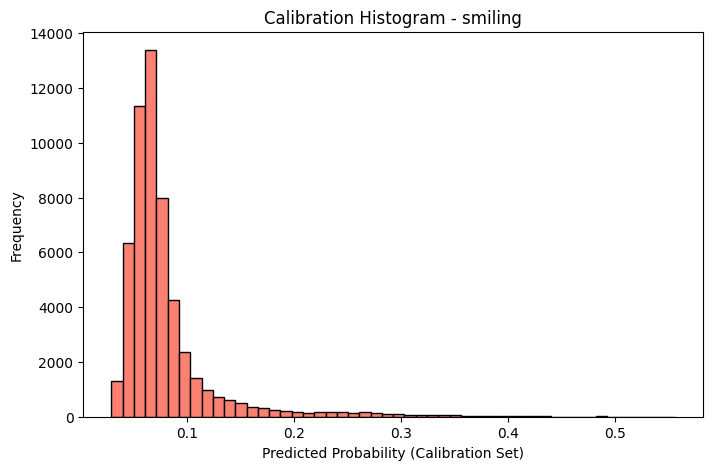

Optimal threshold on calibration set for 'smiling': 0.090, F1: 0.385
1291/1291 ━━━━━━━━━━━━━━━━━━━━ 186s 144ms/step

Classification Report for 'smiling' (using calibrated threshold):
              precision    recall  f1-score   support

           0       0.87      0.82      0.85     33541
           1       0.38      0.46      0.41      7755

    accuracy                           0.76     41296
   macro avg       0.62      0.64      0.63     41296
weighted avg       0.78      0.76      0.76     41296

Test Confusion Matrix:
[[27652  5889]
 [ 4186  3569]]


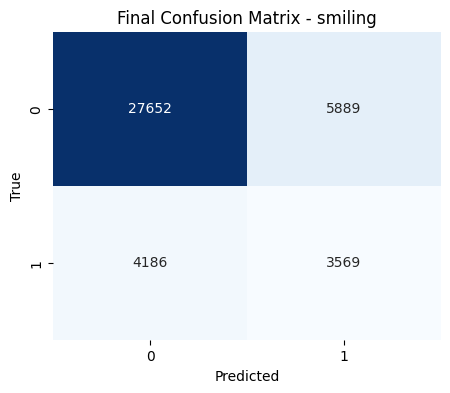

Model for 'smiling' saved as final_model_smiling.keras


Training model for label: fork_towards
Label distribution for 'fork_towards':
fork_towards
0    281261
1     33485
Name: count, dtype: int64
Ratio:
 fork_towards
0    0.893613
1    0.106387
Name: count, dtype: float64
Total sequences created for 'fork_towards': 312766
Train sequences: (271470, 100, 5) Test sequences: (41296, 100, 5)

--- CV Fold 1/4 ---
Training fold label distribution: [169897  20167]
Validation fold label distribution: [72384  9022]


d:\sina-code\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_30                │ (None, 100, 1024)      │     2,121,728 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_31                │ (None, 1024)           │     6,295,552 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,418,305 (32.11 MB)

 Trainable params: 8,418,305 (32.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2970/2970 ━━━━━━━━━━━━━━━━━━━━ 0s 725ms/step - accuracy: 0.8876 - loss: 0.3486 - precision: 0.1358 - recall: 0.0098
Epoch 1: val_loss improved from inf to 0.33740, saving model to best_fork_towards_fold1.keras
2970/2970 ━━━━━━━━━━━━━━━━━━━━ 2492s 838ms/step - accuracy: 0.8876 - loss: 0.3486 - precision: 0.1358 - recall: 0.0098 - val_accuracy: 0.8892 - val_loss: 0.3374 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/20
2970/2970 ━━━━━━━━━━━━━━━━━━━━ 0s 723ms/step - accuracy: 0.8940 - loss: 0.3269 - precision: 0.5388 - recall: 0.0041
Epoch 2: val_loss did not improve from 0.33740
2970/2970 ━━━━━━━━━━━━━━━━━━━━ 2478s 835ms/step - accuracy: 0.8940 - loss: 0.3269 - precision: 0.5388 - recall: 0.0041 - val_accuracy: 0.8892 - val_loss: 0.3424 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/20
2970/2970 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.8955 - loss: 0.3246 - precision: 0.4608 - recall: 0

In [ ]:
# ===============================
# MAIN TRAINING PIPELINE
# ===============================
trained_models = {}

# Example manual class weights: give class 0 double weight
# Adjust as needed (e.g. {0:1.5, 1:1.0}, etc.)
CLASS_WEIGHTS = {0: 2.0, 1: 1.0}

for label in label_cols:
    print("\n==============================================")
    print(f"Training model for label: {label}")
    print("==============================================")
    
    # Basic label stats
    print_label_distribution(data, label)
    
    # Create sequences
    X_full, y_full, vid_full = create_sequences(
        df=data,
        feature_cols=feature_cols,
        label_col=label,
        sequence_length=SEQUENCE_LENGTH,
        step=STEP_SIZE
    )
    print(f"Total sequences created for '{label}': {X_full.shape[0]}")
    
    # Train-test split
    X_train_raw, X_test_raw, y_train_raw, y_test_raw, vid_train, vid_test = train_test_split_by_video(
        X_full, y_full, vid_full, test_size=0.2, shuffle=False
    )
    print("Train sequences:", X_train_raw.shape, "Test sequences:", X_test_raw.shape)
    
    # Cross-validation
    fold_thresholds = []
    fold_accuracies = []
    fold_best_epochs = []
    fold_count = 1
    
    for train_idx, val_idx in video_based_cv_split(vid_train, n_folds=N_FOLDS, shuffle=False):
        print(f"\n--- CV Fold {fold_count}/{N_FOLDS} ---")
        X_tr_fold = X_train_raw[train_idx]
        X_val_fold = X_train_raw[val_idx]
        y_tr_fold = y_train_raw[train_idx]
        y_val_fold = y_train_raw[val_idx]
        
        print("Training fold label distribution:", np.bincount(y_tr_fold.astype(int)))
        print("Validation fold label distribution:", np.bincount(y_val_fold.astype(int)))
        
        X_tr_processed, imputer, scaler = fit_preprocessor(X_tr_fold)
        X_val_processed, _, _ = fit_preprocessor(X_val_fold, imputer, scaler)
        
        model = build_model(input_shape=(SEQUENCE_LENGTH, X_tr_processed.shape[2]))
        model.summary()
        
        es = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1)
        rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
        ckpt_path = f'best_{label}_fold{fold_count}.keras'
        ckpt = ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True, verbose=1)
        
        history = model.fit(
            X_tr_processed, y_tr_fold,
            validation_data=(X_val_processed, y_val_fold),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            #class_weight=CLASS_WEIGHTS,  # <--- ADDING CLASS WEIGHTS HERE
            callbacks=[es, rlr, ckpt],
            verbose=1
        )
        
        best_epoch = np.argmin(history.history['val_loss']) + 1
        fold_best_epochs.append(best_epoch)
        
        model.load_weights(ckpt_path)
        val_loss, val_acc, val_prec, val_rec = model.evaluate(X_val_processed, y_val_fold, verbose=0)
        fold_accuracies.append(val_acc)
        print(f"Fold {fold_count} => Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
        
        # Optimize threshold
        y_probs_val = model.predict(X_val_processed).ravel()
        best_thr, best_f1 = optimize_threshold(y_val_fold, y_probs_val)
        fold_thresholds.append(best_thr)
        print(f"Fold {fold_count} => Best threshold: {best_thr:.3f}, F1: {best_f1:.3f}")
        
        # Probability histogram
        plt.figure(figsize=(5,4))
        plt.hist(y_probs_val, bins=50, color='skyblue', edgecolor='black')
        plt.xlabel("Predicted Probability")
        plt.ylabel("Frequency")
        plt.title(f"Histogram - {label} (Fold {fold_count})")
        plt.show()
        
        # Confusion matrix
        from sklearn.metrics import confusion_matrix
        y_preds_val = (y_probs_val >= best_thr).astype(int)
        cm_val = confusion_matrix(y_val_fold, y_preds_val)
        print(f"Confusion Matrix for Fold {fold_count}:")
        print(cm_val)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f"Confusion Matrix - {label} (Fold {fold_count})")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()
        
        fold_count += 1
    
    aggregated_threshold = np.median(fold_thresholds)
    mean_cv_acc = np.mean(fold_accuracies)
    avg_best_epoch = int(np.mean(fold_best_epochs))
    print(f"\n=== CV Summary for '{label}' ===")
    print(f"Median threshold across folds: {aggregated_threshold:.3f}")
    print(f"Mean CV Accuracy: {mean_cv_acc:.4f}")
    print(f"Avg best epoch: {avg_best_epoch}")
    
    # Final training on all training data
    print(f"\n--- Final Training for '{label}' ---")
    X_train_processed, final_imputer, final_scaler = fit_preprocessor(X_train_raw)
    X_test_processed, _, _ = fit_preprocessor(X_test_raw, final_imputer, final_scaler)
    
    final_model = build_model((SEQUENCE_LENGTH, X_train_processed.shape[2]))
    final_ckpt_path = f'final_model_{label}.keras'
    
    ckpt_final = ModelCheckpoint(final_ckpt_path, monitor='val_loss', save_best_only=True, verbose=1)
    es_final = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1)
    rlr_final = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
    
    final_model.fit(
        X_train_processed, y_train_raw,
        validation_data=(X_test_processed, y_test_raw),
        epochs=avg_best_epoch,
        batch_size=BATCH_SIZE,
        class_weight=CLASS_WEIGHTS,  # <--- APPLYING THE SAME WEIGHTS FOR FINAL TRAIN
        callbacks=[ckpt_final, es_final, rlr_final],
        verbose=1
    )
    
    final_model.load_weights(final_ckpt_path)
    test_loss, test_acc = final_model.evaluate(X_test_processed, y_test_raw, verbose=0)[:2]
    print(f"\nFinal Model for '{label}' => Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
    
    # Calibration
    cal_split = int(len(X_train_processed) * 0.8)
    X_cal = X_train_processed[cal_split:]
    y_cal = y_train_raw[cal_split:]
    y_probs_cal = final_model.predict(X_cal).ravel()
    
    plt.figure(figsize=(8,5))
    plt.hist(y_probs_cal, bins=50, color='salmon', edgecolor='black')
    plt.xlabel("Predicted Probability (Calibration Set)")
    plt.ylabel("Frequency")
    plt.title(f"Calibration Histogram - {label}")
    plt.show()
    
    best_thr_cal, best_f1_cal = optimize_threshold(y_cal, y_probs_cal)
    print(f"Optimal threshold on calibration set for '{label}': {best_thr_cal:.3f}, F1: {best_f1_cal:.3f}")
    
    y_test_probs = final_model.predict(X_test_processed).ravel()
    y_test_preds = (y_test_probs >= best_thr_cal).astype(int)
    
    print(f"\nClassification Report for '{label}' (using calibrated threshold):")
    print(classification_report(y_test_raw, y_test_preds))
    
    cm_test = confusion_matrix(y_test_raw, y_test_preds)
    print("Test Confusion Matrix:")
    print(cm_test)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Final Confusion Matrix - {label}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    
    final_model.save(final_ckpt_path)
    trained_models[label] = final_model
    print(f"Model for '{label}' saved as {final_ckpt_path}\n")

print("All label models trained and evaluated.")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# ===============================
# Configuration & Hyperparameters
# ===============================
SEQUENCE_LENGTH = 100
STEP_SIZE = 1
N_FOLDS = 4
N_LSTM_UNITS = 256
DROPOUT_RATE = 0.2
LEARNING_RATE = 1e-4
BATCH_SIZE = 64
EPOCHS = 20
PATIENCE = 5

USE_FOCAL_LOSS = False  # Turned off focal loss for simplicity

feature_cols = [
    'mouth_width', 'lip_distance', 'wrist_to_mouth_distance', 'wrist_to_mouth_velocity',
    'left_ear_to_lip', 'right_ear_to_lip', 'jaw_to_nose',
    'eyebrow_distance', 'vertical_face_angle', 'vertical_gaze_angle',
    'horizontal_gaze_angle'
]

label_cols = ['speaking', 'eating', 'smiling', 'fork_towards', 'action']

# Load data
data = pd.read_csv('./features-new/combined_labeled_features_sorted.csv')

# ===============================
# 1) Create Sequences (Split by Person in Each Video)
# ===============================
def create_sequences(df, feature_cols, label_col, sequence_length=SEQUENCE_LENGTH, step=STEP_SIZE):
    """
    For each video, treat the first half of the rows as Person 1, second half as Person 2.
    Leftover frames that don't make a full sequence are discarded.
    """
    X_list, y_list, video_ids_list = [], [], []

    for vid, group in df.groupby('video number'):
        group = group.sort_values(by=['frame number']).reset_index(drop=True)
        half = len(group) // 2
        sub1 = group.iloc[:half]
        sub2 = group.iloc[half:]
        
        # Person 1
        feats1 = sub1[feature_cols].values
        labels1 = sub1[label_col].values
        for start_idx in range(0, len(feats1) - sequence_length + 1, step):
            seq_feat = feats1[start_idx : start_idx + sequence_length]
            seq_label = labels1[start_idx + sequence_length - 1]
            X_list.append(seq_feat)
            y_list.append(seq_label)
            video_ids_list.append(vid)
        
        # Person 2
        feats2 = sub2[feature_cols].values
        labels2 = sub2[label_col].values
        for start_idx in range(0, len(feats2) - sequence_length + 1, step):
            seq_feat = feats2[start_idx : start_idx + sequence_length]
            seq_label = labels2[start_idx + sequence_length - 1]
            X_list.append(seq_feat)
            y_list.append(seq_label)
            video_ids_list.append(vid)

    return np.array(X_list), np.array(y_list), np.array(video_ids_list)

# ===============================
# 2) Train-Test Split by Video
# ===============================
def train_test_split_by_video(X, y, video_ids, test_size=0.2, shuffle=False, random_state=42):
    unique_vids = np.unique(video_ids)
    n_test = int(len(unique_vids) * test_size)
    if shuffle:
        rng = np.random.default_rng(seed=random_state)
        rng.shuffle(unique_vids)
    test_vids = unique_vids[-n_test:]
    train_vids = unique_vids[:-n_test]

    train_mask = np.isin(video_ids, train_vids)
    test_mask  = np.isin(video_ids, test_vids)
    return X[train_mask], X[test_mask], y[train_mask], y[test_mask], video_ids[train_mask], video_ids[test_mask]

# ===============================
# 3) Video-Based Cross Validation (Leave-Some-Videos-Out)
# ===============================
def video_based_cv_split(vid_array, n_folds=4, shuffle=False, random_state=42):
    """
    Splits unique video IDs into n_folds. Each fold uses a different subset of videos for validation.
    """
    unique_vids = np.unique(vid_array)
    if shuffle:
        rng = np.random.default_rng(seed=random_state)
        rng.shuffle(unique_vids)
    fold_sizes = np.full(n_folds, len(unique_vids) // n_folds, dtype=int)
    fold_sizes[: len(unique_vids) % n_folds] += 1

    current = 0
    folds = []
    for fold_size in fold_sizes:
        start, stop = current, current + fold_size
        val_vids = unique_vids[start:stop]
        folds.append(val_vids)
        current = stop

    for fold_i in range(n_folds):
        val_vids = folds[fold_i]
        train_vids = np.concatenate([folds[j] for j in range(n_folds) if j != fold_i])

        train_idx = np.where(np.isin(vid_array, train_vids))[0]
        val_idx   = np.where(np.isin(vid_array, val_vids))[0]
        yield train_idx, val_idx

# ===============================
# 4) Preprocessing (Imputation + Scaling)
# ===============================
def fit_preprocessor(data_array, imputer=None, scaler=None):
    n_samples, seq_len, n_features = data_array.shape
    data_2d = data_array.reshape(-1, n_features)

    if imputer is None:
        imputer = SimpleImputer(strategy='mean')
        imputer.fit(data_2d)
    data_imputed = imputer.transform(data_2d)

    if scaler is None:
        scaler = StandardScaler()
        scaler.fit(data_imputed)
    data_scaled = scaler.transform(data_imputed)

    return data_scaled.reshape(n_samples, seq_len, n_features), imputer, scaler

# ===============================
# 5) Build Model (No Focal Loss or Class Weight by Default)
# ===============================
def build_model(input_shape,
                learning_rate=LEARNING_RATE,
                dropout_rate=DROPOUT_RATE,
                n_lstm_units=N_LSTM_UNITS,
                use_focal_loss=USE_FOCAL_LOSS):
    model = Sequential([
        Bidirectional(LSTM(n_lstm_units, return_sequences=True, dropout=dropout_rate),
                      input_shape=input_shape),
        Bidirectional(LSTM(n_lstm_units, dropout=dropout_rate)),
        Dense(128, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    loss_fn = 'binary_crossentropy'
    if use_focal_loss:
        from focal_loss import BinaryFocalLoss
        loss_fn = BinaryFocalLoss(gamma=1)

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=loss_fn,
        metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
    )
    return model

# ===============================
# 6) Undersampling Helper
# ===============================
def undersample_majority_class(X, y, max_ratio=1.0, random_state=42):
    """
    Randomly undersample the majority class (label=0) so that
    #negatives <= max_ratio * #positives.

    If max_ratio=1.0 => #negatives = #positives (50-50).
    If max_ratio=1.5 => #negatives = 1.5 * #positives, etc.

    Returns X_bal, y_bal with undersampled negatives.
    """
    rng = np.random.default_rng(random_state)
    pos_indices = np.where(y == 1)[0]
    neg_indices = np.where(y == 0)[0]

    n_pos = len(pos_indices)
    n_neg = len(neg_indices)
    max_neg = int(max_ratio * n_pos)

    if n_neg > max_neg:
        # We have more negatives than allowed; undersample
        chosen_neg = rng.choice(neg_indices, size=max_neg, replace=False)
        new_indices = np.concatenate([pos_indices, chosen_neg])
        rng.shuffle(new_indices)
        return X[new_indices], y[new_indices]
    else:
        # No undersampling needed
        return X, y

# ===============================
# 7) Threshold Optimization
# ===============================
def optimize_threshold(y_true, y_probs):
    thresholds = np.linspace(0, 1, 101)
    best_thr = 0.5
    best_f1 = 0.0
    for thr in thresholds:
        preds = (y_probs >= thr).astype(int)
        score = f1_score(y_true, preds)
        if score > best_f1:
            best_f1 = score
            best_thr = thr
    return best_thr, best_f1

# ===============================
# Utility to Print Label Distribution
# ===============================
def print_label_distribution(df, label):
    counts = df[label].value_counts(dropna=False)
    print(f"Label distribution for '{label}':\n{counts}")
    print("Ratio:\n", counts / counts.sum())

# ===============================
# MAIN TRAINING PIPELINE
# ===============================
trained_models = {}

# ratio=1.0 => exact 50:50 negative:positive in the training fold
UNDERSAMPLE_RATIO = 1.0

for label in label_cols:
    print("\n==============================================")
    print(f"Training model for label: {label}")
    print("==============================================")
    
    # 1) Basic label stats
    print_label_distribution(data, label)
    
    # 2) Create all sequences
    X_full, y_full, vid_full = create_sequences(
        df=data,
        feature_cols=feature_cols,
        label_col=label,
        sequence_length=SEQUENCE_LENGTH,
        step=STEP_SIZE
    )
    print(f"Total sequences created for '{label}': {X_full.shape[0]}")
    
    # 3) Train-Test Split by Video
    X_train_raw, X_test_raw, y_train_raw, y_test_raw, vid_train, vid_test = train_test_split_by_video(
        X_full, y_full, vid_full, test_size=0.2, shuffle=False
    )
    print("Train sequences:", X_train_raw.shape, "Test sequences:", X_test_raw.shape)
    
    # 4) Video-Based Cross Validation (with Undersampling in each fold)
    fold_thresholds = []
    fold_accuracies = []
    fold_best_epochs = []
    fold_count = 1
    
    for train_idx, val_idx in video_based_cv_split(vid_train, n_folds=N_FOLDS, shuffle=False):
        print(f"\n--- CV Fold {fold_count}/{N_FOLDS} ---")
        
        # Extract fold data
        X_tr_fold, y_tr_fold = X_train_raw[train_idx], y_train_raw[train_idx]
        X_val_fold, y_val_fold = X_train_raw[val_idx], y_train_raw[val_idx]
        
        # Print fold distribution
        print("Training fold label distribution:", np.bincount(y_tr_fold.astype(int)))
        print("Validation fold label distribution:", np.bincount(y_val_fold.astype(int)))
        
        # Undersample the majority class in the training fold
        X_tr_bal, y_tr_bal = undersample_majority_class(
            X_tr_fold, y_tr_fold, max_ratio=UNDERSAMPLE_RATIO
        )
        print("After undersampling training fold:", np.bincount(y_tr_bal.astype(int)))
        
        # Preprocess folds
        X_tr_processed, imputer, scaler = fit_preprocessor(X_tr_bal)
        X_val_processed, _, _ = fit_preprocessor(X_val_fold, imputer, scaler)
        
        # Build & train model
        model = build_model((SEQUENCE_LENGTH, X_tr_processed.shape[2]))
        model.summary()
        
        es = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1)
        rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
        ckpt_path = f'best_{label}_fold{fold_count}.keras'
        ckpt = ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True, verbose=1)
        
        history = model.fit(
            X_tr_processed, y_tr_bal,
            validation_data=(X_val_processed, y_val_fold),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[es, rlr, ckpt],
            verbose=1
        )
        
        best_epoch = np.argmin(history.history['val_loss']) + 1
        fold_best_epochs.append(best_epoch)
        
        # Evaluate on validation
        model.load_weights(ckpt_path)
        val_loss, val_acc, val_prec, val_rec = model.evaluate(X_val_processed, y_val_fold, verbose=0)
        fold_accuracies.append(val_acc)
        print(f"Fold {fold_count} => Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
        
        # Threshold optimization
        y_probs_val = model.predict(X_val_processed).ravel()
        best_thr, best_f1 = optimize_threshold(y_val_fold, y_probs_val)
        fold_thresholds.append(best_thr)
        print(f"Fold {fold_count} => Best threshold: {best_thr:.3f}, F1: {best_f1:.3f}")
        
        # Probability histogram
        plt.figure(figsize=(5,4))
        plt.hist(y_probs_val, bins=50, color='skyblue', edgecolor='black')
        plt.xlabel("Predicted Probability")
        plt.ylabel("Frequency")
        plt.title(f"Histogram - {label} (Fold {fold_count})")
        plt.show()
        
        # Confusion matrix
        y_preds_val = (y_probs_val >= best_thr).astype(int)
        cm_val = confusion_matrix(y_val_fold, y_preds_val)
        print(f"Confusion Matrix for Fold {fold_count}:")
        print(cm_val)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f"Confusion Matrix - {label} (Fold {fold_count})")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()
        
        fold_count += 1
    
    # Aggregate fold results
    aggregated_threshold = np.median(fold_thresholds)
    mean_cv_acc = np.mean(fold_accuracies)
    avg_best_epoch = int(np.mean(fold_best_epochs))
    print(f"\n=== CV Summary for '{label}' ===")
    print(f"Median threshold across folds: {aggregated_threshold:.3f}")
    print(f"Mean CV Accuracy: {mean_cv_acc:.4f}")
    print(f"Avg best epoch: {avg_best_epoch}")
    
    # 5) Final Training on All Training Data (undersampled)
    print(f"\n--- Final Training for '{label}' ---")

    # Undersample entire training set before final training
    X_train_bal, y_train_bal = undersample_majority_class(
        X_train_raw, y_train_raw, max_ratio=UNDERSAMPLE_RATIO
    )
    print("After undersampling full training data:", np.bincount(y_train_bal.astype(int)))

    # Preprocess final train & test sets
    X_train_processed, final_imputer, final_scaler = fit_preprocessor(X_train_bal)
    X_test_processed, _, _ = fit_preprocessor(X_test_raw, final_imputer, final_scaler)
    
    final_model = build_model((SEQUENCE_LENGTH, X_train_processed.shape[2]))
    final_ckpt_path = f'final_model_{label}.keras'
    
    ckpt_final = ModelCheckpoint(final_ckpt_path, monitor='val_loss', save_best_only=True, verbose=1)
    es_final = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1)
    rlr_final = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
    
    final_model.fit(
        X_train_processed, y_train_bal,
        validation_data=(X_test_processed, y_test_raw),
        epochs=avg_best_epoch,
        batch_size=BATCH_SIZE,
        callbacks=[ckpt_final, es_final, rlr_final],
        verbose=1
    )
    
    final_model.load_weights(final_ckpt_path)
    test_loss, test_acc = final_model.evaluate(X_test_processed, y_test_raw, verbose=0)[:2]
    print(f"\nFinal Model for '{label}' => Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
    
    # ---- Calibration Step for Final Threshold ----
    cal_split = int(len(X_train_processed) * 0.8)
    X_cal = X_train_processed[cal_split:]
    y_cal = y_train_bal[cal_split:]
    y_probs_cal = final_model.predict(X_cal).ravel()
    
    plt.figure(figsize=(8,5))
    plt.hist(y_probs_cal, bins=50, color='salmon', edgecolor='black')
    plt.xlabel("Predicted Probability (Calibration Set)")
    plt.ylabel("Frequency")
    plt.title(f"Calibration Histogram - {label}")
    plt.show()
    
    best_thr_cal, best_f1_cal = optimize_threshold(y_cal, y_probs_cal)
    print(f"Optimal threshold on calibration set for '{label}': {best_thr_cal:.3f}, F1: {best_f1_cal:.3f}")
    
    # Apply final threshold on test set
    y_test_probs = final_model.predict(X_test_processed).ravel()
    y_test_preds = (y_test_probs >= best_thr_cal).astype(int)
    
    print(f"\nClassification Report for '{label}' (using calibrated threshold):")
    print(classification_report(y_test_raw, y_test_preds))
    
    cm_test = confusion_matrix(y_test_raw, y_test_preds)
    print("Test Confusion Matrix:")
    print(cm_test)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Final Confusion Matrix - {label}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    
    final_model.save(final_ckpt_path)
    trained_models[label] = final_model
    print(f"Model for '{label}' saved as {final_ckpt_path}\n")

print("All label models trained and evaluated.")
